In [1]:
import numpy as np
import pandas as pd
import glob
import os

In [2]:
import pandas as pd

def unify_tabular_data(oid, tabular):
    # 1. Trabajamos sobre una copia para no afectar el original
    df = tabular.copy()
    
    # 2. Lógica Vectorizada: Crear una columna 'key'
    # Por defecto la llave es el 'name'
    df['key'] = df['name']
    
    # Si 'fid' NO es None, la llave es 'name_fid'
    mask = ~df["fid"].isin([None])
    df.loc[mask, 'key'] = df.loc[mask, 'name'] + "_" + df.loc[mask, 'fid']
    
    # 3. Transponer: Convertir filas en columnas (Pivotar)
    # Tomamos la columna 'key' como índice y 'value' como valor, y giramos la tabla
    res = df.set_index('key')[['value']].T
    
    # 4. Asignamos el OID
    res.index = [oid]
    res.index.name = 'oid'
    res.columns.name = None 
    
    return res

In [3]:
path_feat = "../results_prod/objs_rand350000_2025-12-23_fromdb_ndetcleange8_ao_251223_features"
path_squid = "../results_prod/objs_rand350000_2025-12-23_fromdb_ndetcleange8_ao_251223_squidward"
path_mbappe = "../results_prod/objs_rand350000_2025-12-23_fromdb_ndetcleange8_ao_251223_mbappe"

In [4]:
path_chunks_feat = glob.glob(f'{path_feat}/*')
path_chunks_squid = glob.glob(f'{path_squid}/*')
path_chunks_mbappe = glob.glob(f'{path_mbappe}/*')
print(len(path_chunks_feat))
print(len(path_chunks_squid))
print(len(path_chunks_mbappe))

146
146
146


In [5]:
def extract_info(path_chunk):
    
    astro_objects_batch = pd.read_pickle("{}".format(path_chunk))

    df_features = []
    for i, astro_object in enumerate(astro_objects_batch):
        oid = astro_object['detections'].index[0]
        features_obj = astro_object['features']
        features_obj = unify_tabular_data(oid, features_obj)

        df_features.append(features_obj)

    df_features = pd.concat(df_features)

    return df_features

In [6]:
import multiprocessing
import tqdm

num_cores = 15

with multiprocessing.Pool(processes=num_cores) as pool:
    df_features = list(
        tqdm.tqdm(
            pool.imap_unordered(extract_info, path_chunks_feat),
            total=len(path_chunks_feat),
        )
    )

df_features = pd.concat(df_features)
df_features.index = df_features.index.str.replace('aid_', '')
df_features

  0%|          | 0/146 [00:00<?, ?it/s]

 52%|█████▏    | 76/146 [00:49<00:45,  1.53it/s]Process ForkPoolWorker-10:
Process ForkPoolWorker-11:
Process ForkPoolWorker-9:
Process ForkPoolWorker-3:
Process ForkPoolWorker-6:
Process ForkPoolWorker-8:
Process ForkPoolWorker-13:
Process ForkPoolWorker-14:
Process ForkPoolWorker-7:
Process ForkPoolWorker-4:



KeyboardInterrupt: 

In [ ]:
df_probs_squid = []
for path_chunk_prob in path_chunks_squid:
    probs = pd.read_parquet(path_chunk_prob)
    df_probs_squid.append(probs)

df_probs_squid = pd.concat(df_probs_squid)
df_probs_squid

,class_name,probability,ranking,classifier_name,classifier_version
oid,,,,,
ZTF19abnhbey,CV/Nova,0.281464,1,lc_classifier_BHRF_forced_phot,2.1.0_bp
ZTF19abnhbey,YSO,0.098792,2,lc_classifier_BHRF_forced_phot,2.1.0_bp
ZTF19abnhbey,EA,0.098000,3,lc_classifier_BHRF_forced_phot,2.1.0_bp
ZTF19abnhbey,CEP,0.082320,4,lc_classifier_BHRF_forced_phot,2.1.0_bp
ZTF19abnhbey,Periodic-Other,0.071540,5,lc_classifier_BHRF_forced_phot,2.1.0_bp
...,...,...,...,...,...
ZTF18aawsakr,YSO,0.216000,2,lc_classifier_BHRF_forced_phot_stochastic,2.1.0_bp
ZTF18aawsakr,Blazar,0.084000,3,lc_classifier_BHRF_forced_phot_stochastic,2.1.0_bp
ZTF18aawsakr,Microlensing,0.082000,4,lc_classifier_BHRF_forced_phot_stochastic,2.1.0_bp


In [ ]:
bottom_squid_name = 'lc_classifier_BHRF_forced_phot'
bottom_mbappe_name = 'LC_classifier_ATAT_forced_phot(beta)'

df_probs_squid_rank1 = df_probs_squid[df_probs_squid.ranking == 1]
df_probs_squid_rank1_bottom = df_probs_squid_rank1[df_probs_squid_rank1.classifier_name == bottom_squid_name]

In [ ]:
df_probs_squid_rank1_bottom['class_name'].value_counts()

class_name
YSO               86592
CV/Nova           63007
EB/EW             16435
Microlensing       8681
EA                 8208
Periodic-Other     6435
RSCVn              5928
RRLab              5548
RRLc               4725
LPV                4465
CEP                2918
DSCT               1331
QSO                 674
SNII                593
TDE                 345
SNIIn               293
SNIa                224
SLSN                192
AGN                 187
Blazar              141
SESN                 63
Name: count, dtype: int64

In [ ]:
df_probs_mbappe = []
for path_chunk_prob in path_chunks_mbappe:
    probs = pd.read_parquet(path_chunk_prob)
    df_probs_mbappe.append(probs)

df_probs_mbappe = pd.concat(df_probs_mbappe)
df_probs_mbappe

,class_name,probability,ranking,classifier_name,classifier_version
oid,,,,,
ZTF19abnhbey,Periodic-Other,3.402351e-01,1,LC_classifier_ATAT_forced_phot(beta),1.1.0_bp
ZTF19abnhbey,RSCVn,1.536917e-01,2,LC_classifier_ATAT_forced_phot(beta),1.1.0_bp
ZTF19abnhbey,CEP,1.438579e-01,3,LC_classifier_ATAT_forced_phot(beta),1.1.0_bp
ZTF19abnhbey,EB/EW,9.827146e-02,4,LC_classifier_ATAT_forced_phot(beta),1.1.0_bp
ZTF19abnhbey,EA,9.520041e-02,5,LC_classifier_ATAT_forced_phot(beta),1.1.0_bp
...,...,...,...,...,...
ZTF18aawsakr,SESN,6.023893e-07,17,LC_classifier_ATAT_forced_phot(beta),1.1.0_bp
ZTF18aawsakr,Microlensing,1.015881e-07,18,LC_classifier_ATAT_forced_phot(beta),1.1.0_bp
ZTF18aawsakr,SNIIn,1.903564e-08,19,LC_classifier_ATAT_forced_phot(beta),1.1.0_bp


In [ ]:
bottom_squid_name = 'lc_classifier_BHRF_forced_phot'
bottom_mbappe_name = 'LC_classifier_ATAT_forced_phot(beta)'

In [ ]:
prob_squid_wide_bottom = df_probs_squid[df_probs_squid.classifier_name == bottom_squid_name].pivot_table(
    index="oid",
    columns="class_name",
    values="probability"
)

prob_squid_wide_bottom

class_name,AGN,Blazar,CEP,CV/Nova,DSCT,EA,EB/EW,LPV,Microlensing,Periodic-Other,...,RRLab,RRLc,RSCVn,SESN,SLSN,SNII,SNIIn,SNIa,TDE,YSO
oid,,,,,,,,,,,,,,,,,,,,,
ZTF17aaaaaat,0.000600,0.002160,0.039228,0.022320,0.072852,0.078456,0.465132,0.000000,0.003360,0.104608,...,0.044832,0.104608,0.024284,0.001056,0.000708,0.001248,0.001404,0.000624,0.000960,0.031200
ZTF17aaaaabl,0.000828,0.004140,0.172992,0.042228,0.001696,0.049184,0.047488,0.010176,0.006072,0.027136,...,0.468096,0.052576,0.018656,0.002464,0.002016,0.002800,0.002912,0.001680,0.002128,0.083904
ZTF17aaaaadw,0.001080,0.006912,0.260452,0.054864,0.003496,0.201020,0.061180,0.012236,0.007128,0.043700,...,0.201020,0.027968,0.062928,0.003204,0.002304,0.003600,0.003744,0.001620,0.003528,0.036936
ZTF17aaaaakl,0.005840,0.018688,0.108360,0.068328,0.013244,0.113176,0.044548,0.031304,0.045552,0.080668,...,0.026488,0.020468,0.163744,0.019504,0.008268,0.030104,0.021836,0.019716,0.006572,0.148920
ZTF17aaaaakn,0.002520,0.003960,0.123816,0.033840,0.011256,0.167232,0.305520,0.036984,0.021960,0.070752,...,0.025728,0.043416,0.019296,0.003232,0.002144,0.003232,0.003872,0.002048,0.001472,0.117720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZTF25acitown,0.002944,0.002944,0.001848,0.021312,0.004704,0.001792,0.000560,0.000336,0.001664,0.008904,...,0.002296,0.004424,0.003136,0.280120,0.039480,0.157920,0.095880,0.319600,0.047000,0.001600
ZTF25aciutou,0.023200,0.038976,0.060240,0.161472,0.028112,0.055220,0.047188,0.011044,0.045472,0.075300,...,0.033132,0.038152,0.153612,0.008024,0.003264,0.007752,0.005236,0.005848,0.003876,0.167968
ZTF25acjnvql,0.021600,0.092880,0.056032,0.210600,0.014832,0.045320,0.026368,0.009064,0.063720,0.032136,...,0.109592,0.050264,0.068392,0.003264,0.004800,0.005952,0.004512,0.007776,0.021696,0.093960


In [ ]:
prob_mbappe_wide_bottom = df_probs_mbappe[df_probs_mbappe.classifier_name == bottom_mbappe_name].pivot_table(
    index="oid",
    columns="class_name",
    values="probability"
)

prob_mbappe_wide_bottom

class_name,AGN,Blazar,CEP,CV/Nova,DSCT,EA,EB/EW,LPV,Microlensing,Periodic-Other,...,RRLab,RRLc,RSCVn,SESN,SLSN,SNII,SNIIn,SNIa,TDE,YSO
oid,,,,,,,,,,,,,,,,,,,,,
ZTF17aaaaaat,1.478616e-07,1.003724e-07,0.069242,0.000122,1.695875e-03,0.020969,0.579318,5.394571e-06,4.951217e-13,1.308109e-03,...,1.188893e-03,3.193560e-01,0.006684,3.430585e-12,1.159486e-12,6.048885e-08,1.546460e-10,2.438579e-08,1.172529e-13,1.110422e-04
ZTF17aaaaabl,1.869057e-05,6.922901e-06,0.479074,0.002026,1.809839e-04,0.000770,0.001676,1.268834e-03,1.786781e-11,3.387112e-06,...,1.170113e-01,2.364392e-02,0.000119,6.752666e-09,5.646741e-16,2.927766e-09,4.910631e-17,2.969875e-09,1.834490e-14,3.741841e-01
ZTF17aaaaadw,3.716162e-08,1.297241e-06,0.011596,0.000252,1.675518e-04,0.818659,0.126865,2.187642e-05,3.223427e-08,2.446473e-04,...,2.906536e-02,1.142427e-02,0.000900,4.539727e-11,1.416482e-12,8.178748e-08,5.753350e-13,1.013266e-06,2.152537e-09,8.017730e-04
ZTF17aaaaakl,4.120453e-07,1.674752e-05,0.534085,0.001844,7.718548e-03,0.150945,0.114436,1.455839e-02,1.831411e-10,2.591357e-03,...,3.480131e-02,1.361826e-02,0.084776,8.740755e-10,1.075057e-14,8.169303e-09,3.563087e-10,7.481640e-07,2.490225e-15,4.060699e-02
ZTF17aaaaakn,2.814124e-09,3.853270e-07,0.015342,0.000099,1.903719e-04,0.183423,0.789309,2.773324e-05,3.448616e-12,6.718101e-05,...,4.628343e-04,1.060201e-02,0.000360,8.006176e-10,2.132682e-12,4.684773e-09,1.022182e-08,3.685049e-08,3.160021e-15,1.167541e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZTF25acitown,8.396663e-04,3.077375e-06,0.000006,0.000016,7.026531e-09,0.000005,0.000001,6.290165e-08,5.781346e-16,7.705221e-09,...,5.300612e-07,6.483289e-07,0.000001,8.386241e-01,7.895856e-05,1.508956e-02,3.443280e-04,1.449570e-01,3.778107e-07,9.417762e-08
ZTF25aciutou,7.774837e-02,6.537261e-02,0.021310,0.146535,1.300388e-03,0.018401,0.029145,4.869030e-03,8.230722e-08,2.168285e-02,...,2.091936e-02,7.470230e-03,0.171041,3.495146e-06,6.561102e-10,7.991809e-04,4.251142e-09,6.892216e-05,4.138148e-07,4.587583e-02
ZTF25acjnvql,4.167436e-03,2.252108e-03,0.088827,0.550976,9.005869e-04,0.061889,0.027662,4.569937e-03,3.343346e-08,6.913703e-04,...,2.039704e-01,3.243589e-02,0.008464,1.119111e-04,1.458714e-09,6.756024e-06,3.837172e-07,2.754045e-04,3.737049e-06,1.622039e-03


In [ ]:
df_features_coord = df_features[['Coordinate_x', 'Coordinate_y', 'Coordinate_z']]
df_features_coord

,Coordinate_x,Coordinate_y,Coordinate_z
oid,,,
ZTF18adazzhl,-0.671015,0.337715,0.660066
ZTF18adcbntm,0.459360,0.477559,0.748950
ZTF18adbcqqu,0.415151,0.340577,0.843598
ZTF18adbnezn,-0.082653,0.951024,0.297861
ZTF18adbmmnm,0.275945,0.799026,0.534239
...,...,...,...
ZTF19abajinh,0.615481,-0.652637,0.441868
ZTF19abajjba,0.723865,-0.539360,0.430244
ZTF19abapfay,-0.020282,-0.995670,-0.090720


In [ ]:
class_names = [
    "SNIa", "SESN", "SNII", "SNIIn", "SLSN", 
    "TDE", "Microlensing", "QSO", "AGN", "Blazar", 
    "YSO", "CV/Nova", "LPV", "EA", "EB/EW", 
    "Periodic-Other", "RSCVn", "CEP", "RRLab", "RRLc", "DSCT"
    ]

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from astropy.coordinates import SkyCoord
import astropy.units as u
import math

# --- 1. PREPARACIÓN DE DATOS CORREGIDA ---
from astropy.coordinates import SkyCoord
import astropy.units as u


def plot_spatial_distribution(probs):
    # Unimos coordenadas con probabilidades
    df = df_features_coord.join(probs, how='inner')

    # INTERPRETACIÓN CORRECTA DE TUS COORDENADAS
    # Asumimos que x, y, z son Ecuatoriales (ICRS) porque es el estándar de ZTF/Alerce
    coords_icrs = SkyCoord(
        x=df['Coordinate_x'].values, 
        y=df['Coordinate_y'].values, 
        z=df['Coordinate_z'].values, 
        representation_type='cartesian',
        frame='icrs'  # Sistema Ecuatorial estándar
    )

    # Transformamos matemáticamente a Galácticas
    coords_galactic = coords_icrs.transform_to('galactic')

    # Ahora sí tenemos l y b reales
    df['l'] = coords_galactic.l.deg
    df['b'] = coords_galactic.b.deg

    # Determinar la clase predicha
    df['predicted_class'] = df[class_names].idxmax(axis=1)

    # --- 2. CONFIGURACIÓN DEL GRÁFICO ---

    # Calculamos el tamaño del grid
    # Queremos 1 gráfico general + N clases
    total_plots = 1 + len(class_names)
    ncols = 3  # Puedes cambiar esto a 2 o 4 según prefieras
    nrows = math.ceil(total_plots / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(25, 5*nrows), sharex=False, sharey=False)
    axes = axes.flatten()

    # --- 3. CURVA ECLÍPTICA ---
    def get_ecliptic_curve():
        l_ecl = np.linspace(0, 360, 360)
        coords = SkyCoord(lon=l_ecl*u.deg, lat=0*u.deg, frame='barycentrictrueecliptic')
        gal = coords.transform_to('galactic')
        sort_idx = np.argsort(gal.l.deg)
        return gal.l.deg[sort_idx], gal.b.deg[sort_idx]

    ecl_l, ecl_b = get_ecliptic_curve()

    # --- 4. GENERACIÓN DE LOS PLOTS ---

    # Lista de títulos a iterar: Primero 'All Data', luego cada clase
    plot_list = ['All Data'] + class_names

    for i, ax in enumerate(axes):
        if i >= len(plot_list):
            ax.axis('off') # Apagar subplots vacíos
            continue

        current_class = plot_list[i]
        
        # Filtrar datos
        if current_class == 'All Data':
            subset = df # Todos los datos
        else:
            # Solo filas donde la clase ganadora es la actual
            subset = df[df['predicted_class'] == current_class]

        # Graficar si hay datos
        if len(subset) > 0:
            h = ax.hist2d(subset['l'], subset['b'], bins=[180, 90], range=[[0, 360], [-90, 90]], 
                        cmap='viridis', cmin=1)
            plt.colorbar(h[3], ax=ax, fraction=0.046, pad=0.04)
        
        # Dibujar Eclíptica
        ax.plot(ecl_l, ecl_b, 'y-', linewidth=2, 
                path_effects=[pe.withStroke(linewidth=4, foreground="black")], 
                label='Ecliptic')

        # Estética
        ax.set_title(current_class, fontsize=14, fontweight='bold')
        ax.set_xlim(0, 360)
        ax.set_ylim(-90, 90)
        ax.grid(True, linestyle=':', alpha=0.4)
        
        # Labels solo en bordes (opcional, para limpieza)
        if i % ncols == 0:
            ax.set_ylabel("Galactic Latitude (b)")
        if i >= total_plots - ncols:
            ax.set_xlabel("Galactic Longitude (l)")

    plt.tight_layout()
    plt.show()

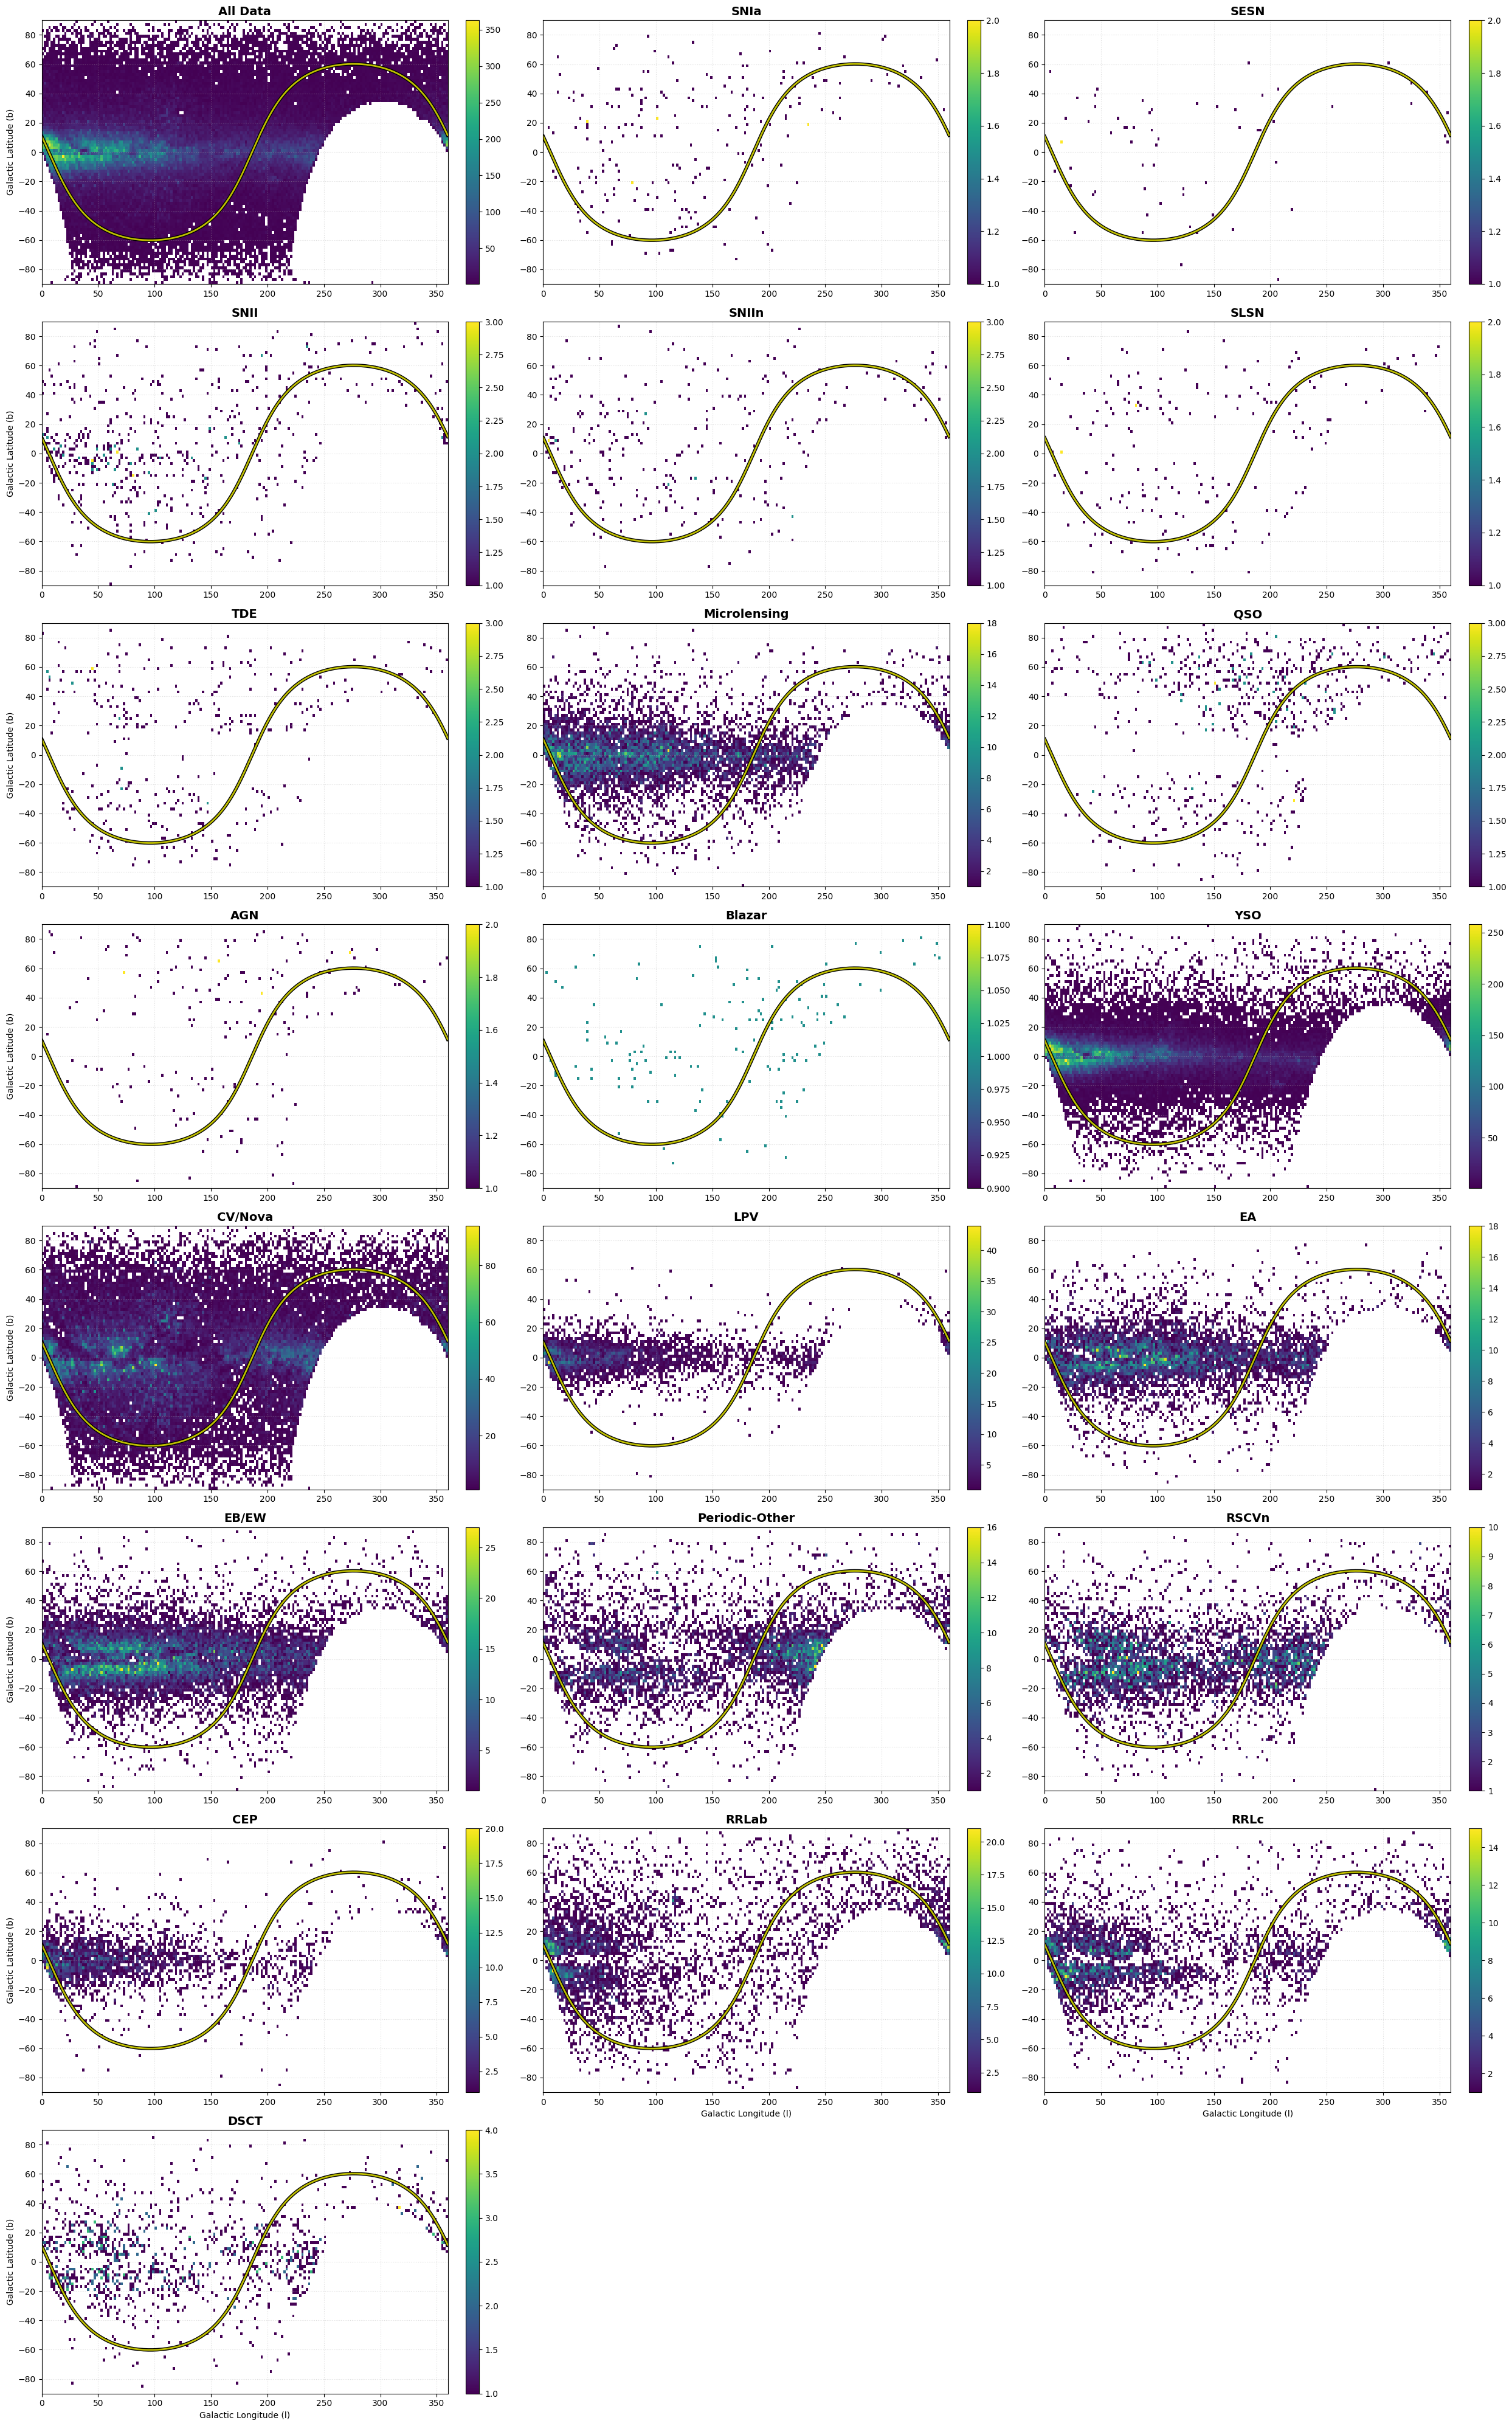

In [ ]:
plot_spatial_distribution(prob_squid_wide_bottom)

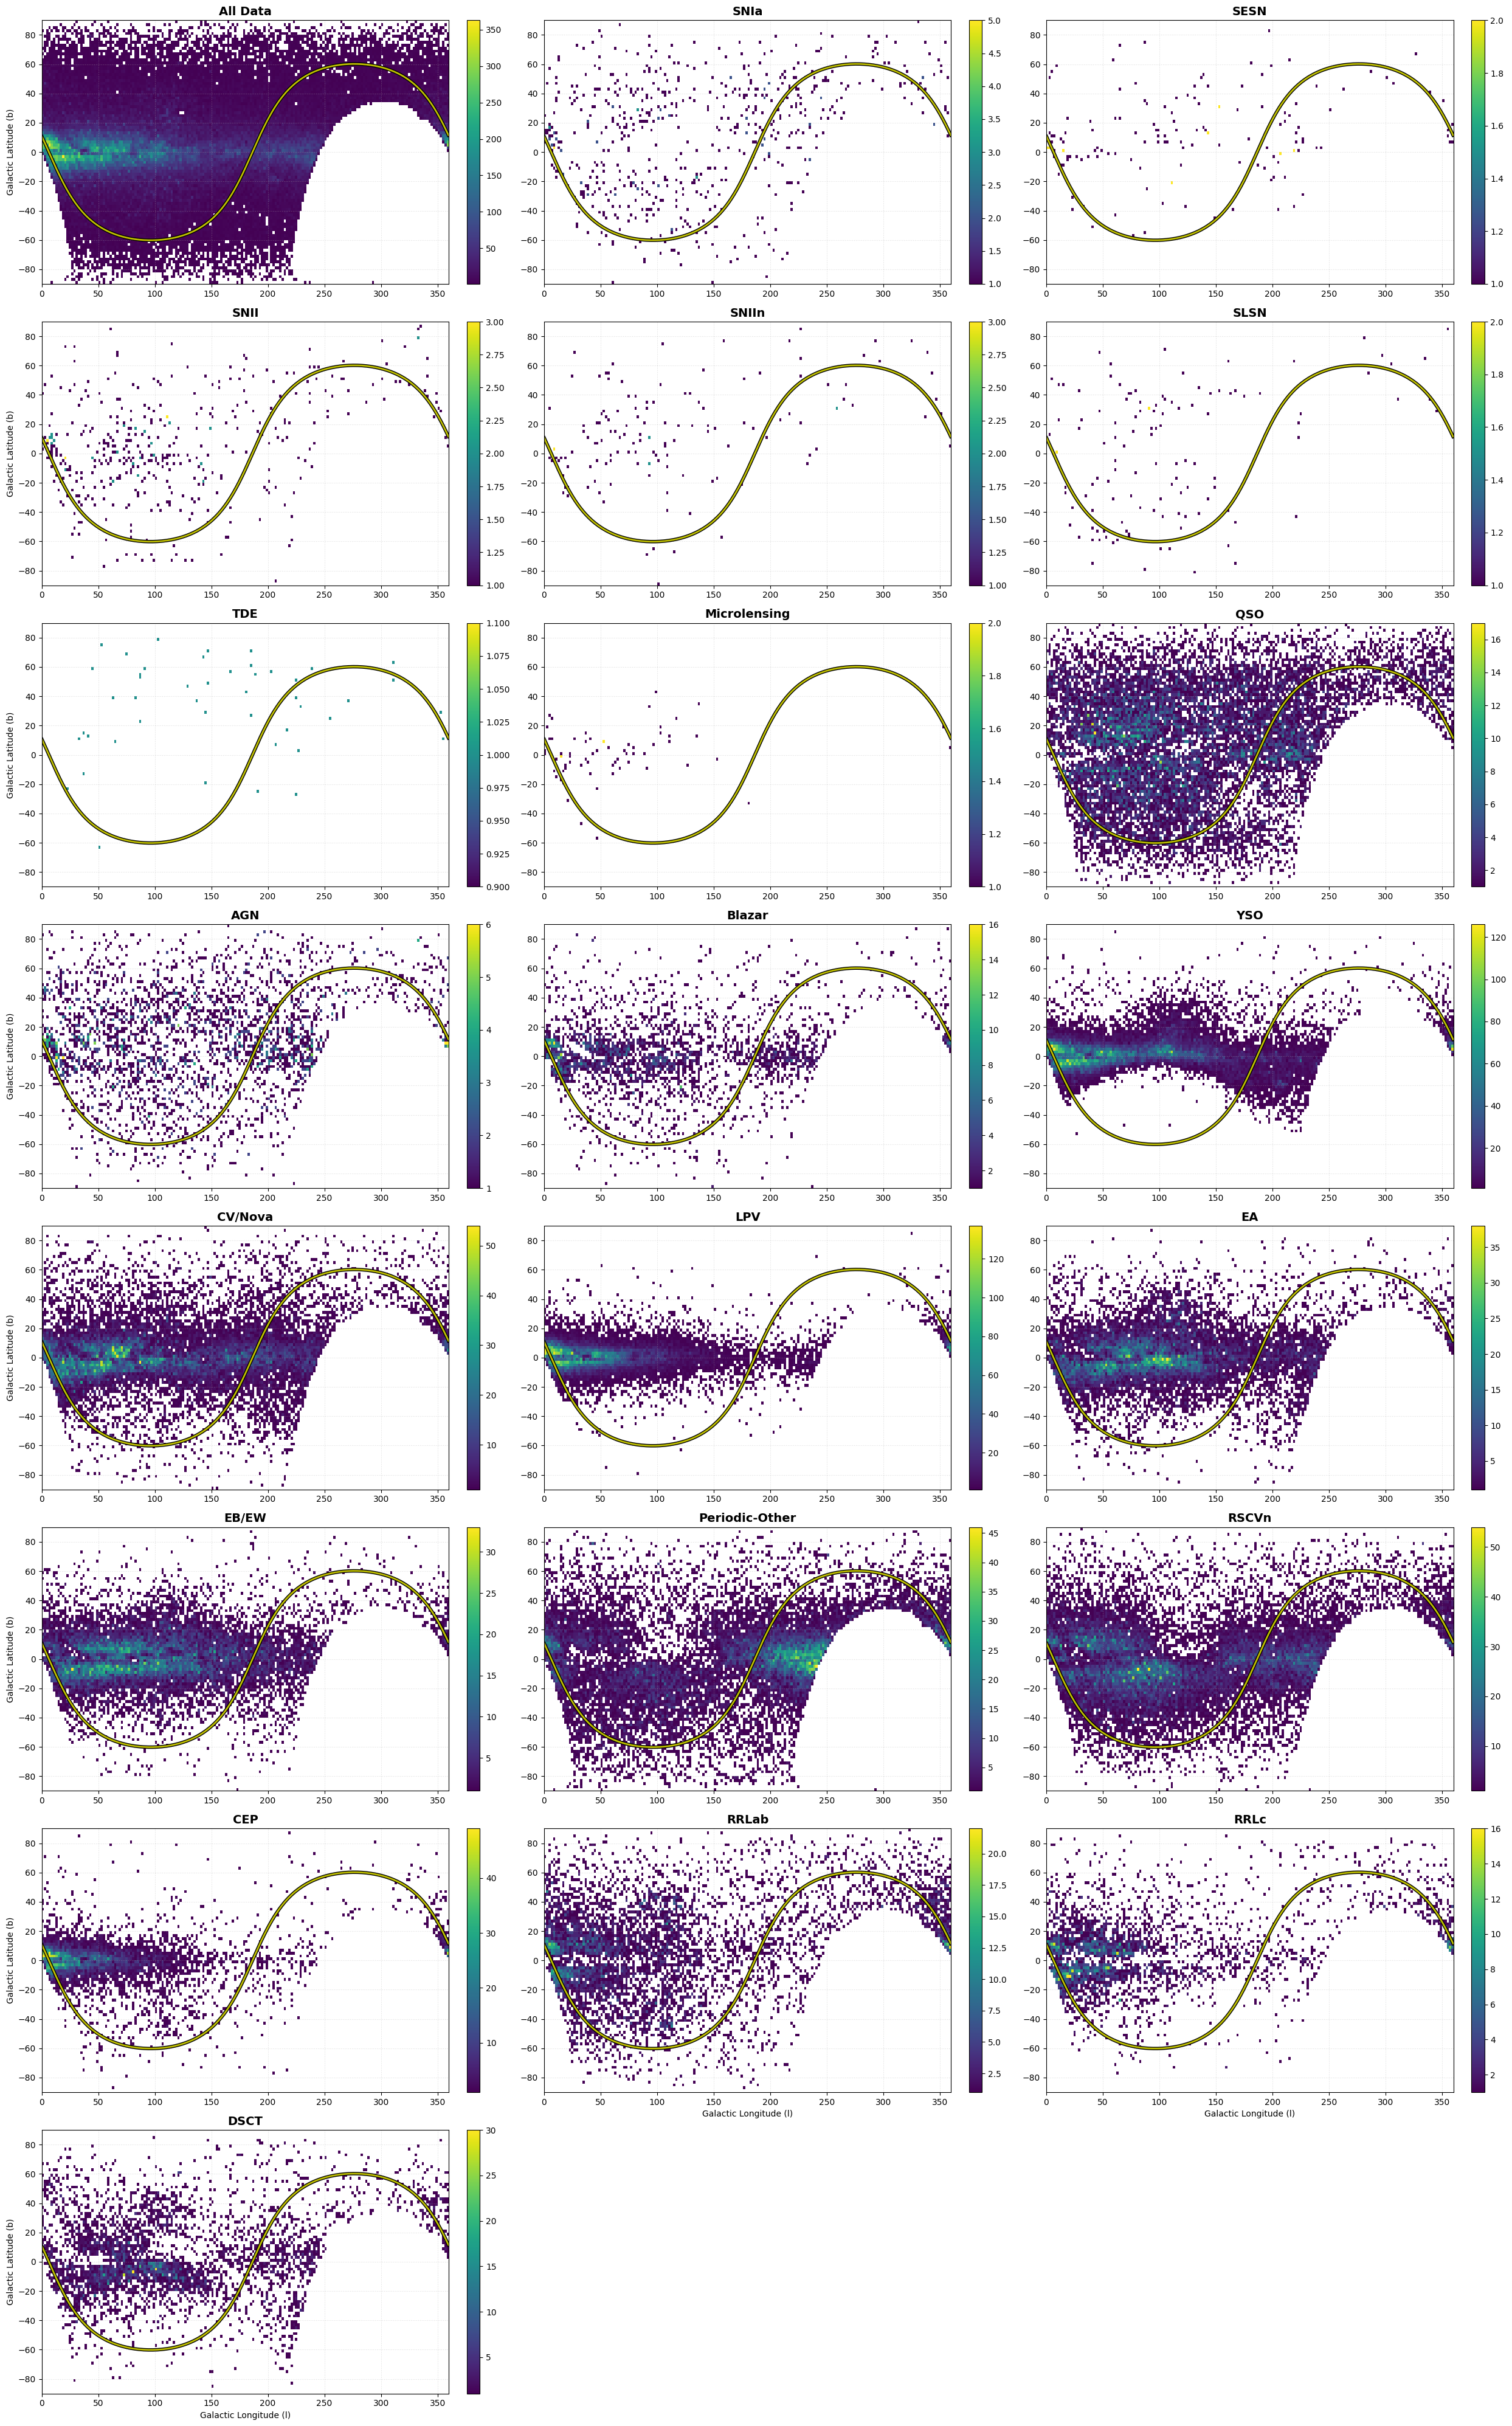

In [ ]:
plot_spatial_distribution(prob_mbappe_wide_bottom)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage
from astropy.coordinates import SkyCoord

# --- 1. DEFINICIÓN DE CLASES ---
extragalactic_classes = [
    "SNIa", "SESN", "SNII", "SNIIn", "SLSN", 
    "TDE", "QSO", "AGN", "Blazar"
]

galactic_classes = [
    "YSO", "CV/Nova", "LPV", "EA", "EB/EW", 
    "Periodic-Other", "RSCVn", "CEP", "RRLab", "RRLc", "DSCT", 
    "Microlensing" 
]

# --- 2. PREPARACIÓN DE DATOS ---
def prepare_data(df_features, df_probs):
    # Unir features con probabilidades
    # Usamos intersection de índices para asegurar que coincidan
    df = df_features.join(df_probs, how='inner')
    
    # --- Coordenadas ---
    # Convertir Cartesianas (x,y,z) a Galácticas (l,b)
    c = SkyCoord(x=df['Coordinate_x'].values, 
                 y=df['Coordinate_y'].values, 
                 z=df['Coordinate_z'].values, 
                 representation_type='cartesian', frame='icrs')
    gal = c.galactic
    df['l'] = gal.l.deg
    df['b'] = gal.b.deg
    
    # --- Predicción ---
    # Asumimos que df_probs tiene las columnas de las clases
    class_cols = df_probs.columns
    df['predicted_class'] = df[class_cols].idxmax(axis=1)
    df['max_prob'] = df[class_cols].max(axis=1)
    
    # --- Color (g-r) ---
    # ACTUALIZACIÓN: Usamos los nombres de tus columnas nuevas
    if 'g-r_mean_corr_g,r' in df.columns:
        # Prioridad 1: Color medio corregido por extinción
        df['color_gr'] = df['g-r_mean_corr_g,r']
    elif 'g-r_mean_g,r' in df.columns:
        # Prioridad 2: Color medio observado
        df['color_gr'] = df['g-r_mean_g,r']
    else:
        # Fallback: Calcularlo manualmente con las medias
        df['color_gr'] = df['Mean_g'] - df['Mean_r']
        
    return df

# --- 3. FUNCIÓN DE CONTORNOS ---
def plot_density_contours(x, y, ax, bins=50, levels=6, color='red'):
    """Dibuja contornos de densidad suavizados (estilo mapa topográfico)"""
    mask = np.isfinite(x) & np.isfinite(y)
    x_clean = x[mask]
    y_clean = y[mask]
    
    if len(x_clean) < 10: return 

    # Histograma 2D
    H, xedges, yedges = np.histogram2d(x_clean, y_clean, bins=bins)
    
    # Suavizado para que las curvas se vean orgánicas
    H_smooth = scipy.ndimage.gaussian_filter(H, sigma=1.5)
    
    xcenters = (xedges[:-1] + xedges[1:]) / 2
    ycenters = (yedges[:-1] + yedges[1:]) / 2
    
    # Dibujar
    ax.contour(xcenters, ycenters, H_smooth.T, levels=levels, 
               colors=color, linewidths=1.2, alpha=0.9)

# --- 4. GRAFICAR FIGURA 17 ---
def plot_figure_17_updated(df):
    # Filtrar subconjuntos
    df_gal = df[df['predicted_class'].isin(galactic_classes)]
    df_ext = df[df['predicted_class'].isin(extragalactic_classes)]
    
    # Crear figura (1 fila, 2 columnas, comparten eje Y de latitud)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
    
    cmap = 'viridis' 
    point_size = 2   
    # Ajusta vmin/vmax a la realidad de tus probabilidades (ej. 0.3 a 0.9)
    vmin, vmax = 0.2, 0.8 
    
    # --- PANEL IZQUIERDO: GALACTIC (l vs b) ---
    if not df_gal.empty:
        sc1 = ax1.scatter(df_gal['l'], df_gal['b'], c=df_gal['max_prob'], 
                          s=point_size, cmap=cmap, vmin=vmin, vmax=vmax, rasterized=True)
        plot_density_contours(df_gal['l'], df_gal['b'], ax1, bins=[60, 40])
    
    ax1.set_xlim(0, 360)
    ax1.set_ylim(-90, 90)
    ax1.set_xlabel("Galactic longitude (gal l) [deg]", fontsize=14)
    ax1.set_ylabel("Galactic latitude (gal b) [deg]", fontsize=14)
    ax1.set_title("Galactic Candidates", fontsize=14, fontweight='bold')
    ax1.grid(True, linestyle=':', alpha=0.3)

    # --- PANEL DERECHO: EXTRAGALACTIC (g-r vs b) ---
    if not df_ext.empty:
        sc2 = ax2.scatter(df_ext['color_gr'], df_ext['b'], c=df_ext['max_prob'], 
                          s=point_size, cmap=cmap, vmin=vmin, vmax=vmax, rasterized=True)
        plot_density_contours(df_ext['color_gr'], df_ext['b'], ax2, bins=[60, 40])

    # El color g-r suele estar entre -0.5 y 2.5 para la mayoría de objetos
    ax2.set_xlim(-1, 3) 
    ax2.set_xlabel(r"$g - r_{mean}$", fontsize=14)
    ax2.set_title("Extragalactic Candidates", fontsize=14, fontweight='bold')
    ax2.grid(True, linestyle=':', alpha=0.3)

    # --- BARRA DE COLOR ---
    fig.subplots_adjust(right=0.90, wspace=0.05) 
    cbar_ax = fig.add_axes([0.91, 0.12, 0.015, 0.76]) 
    
    mappable = sc2 if not df_ext.empty else sc1
    cbar = fig.colorbar(mappable, cax=cbar_ax)
    cbar.set_label("Predicted bottom level probability (P)", fontsize=14)
    
    plt.show()


Calculando coordenadas galácticas...


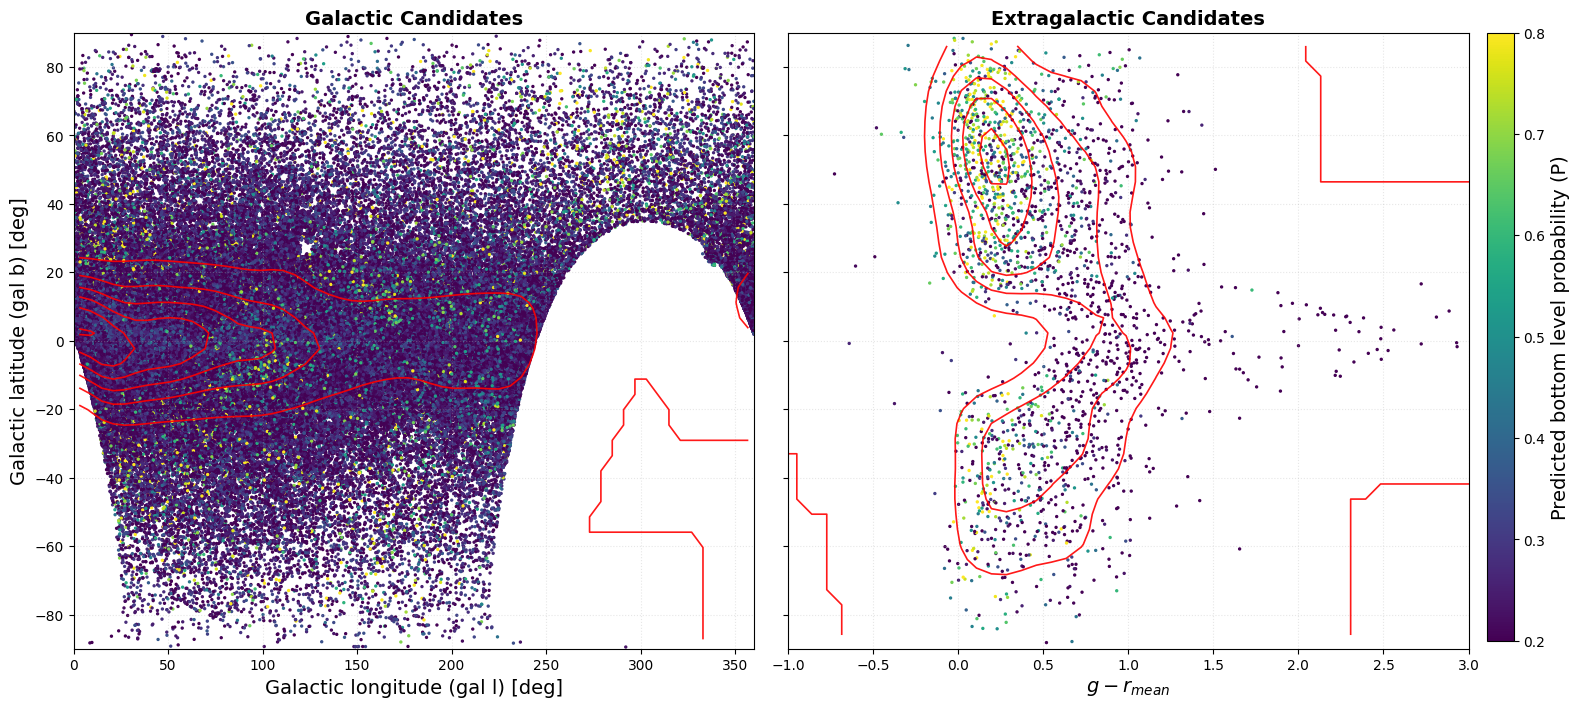

In [43]:
# --- EJECUCIÓN ---
# Asegúrate de que df_features y probs existen en tu entorno
full_df = prepare_data(df_features, prob_squid_wide_bottom)
plot_figure_17_updated(full_df)

Calculando coordenadas galácticas...


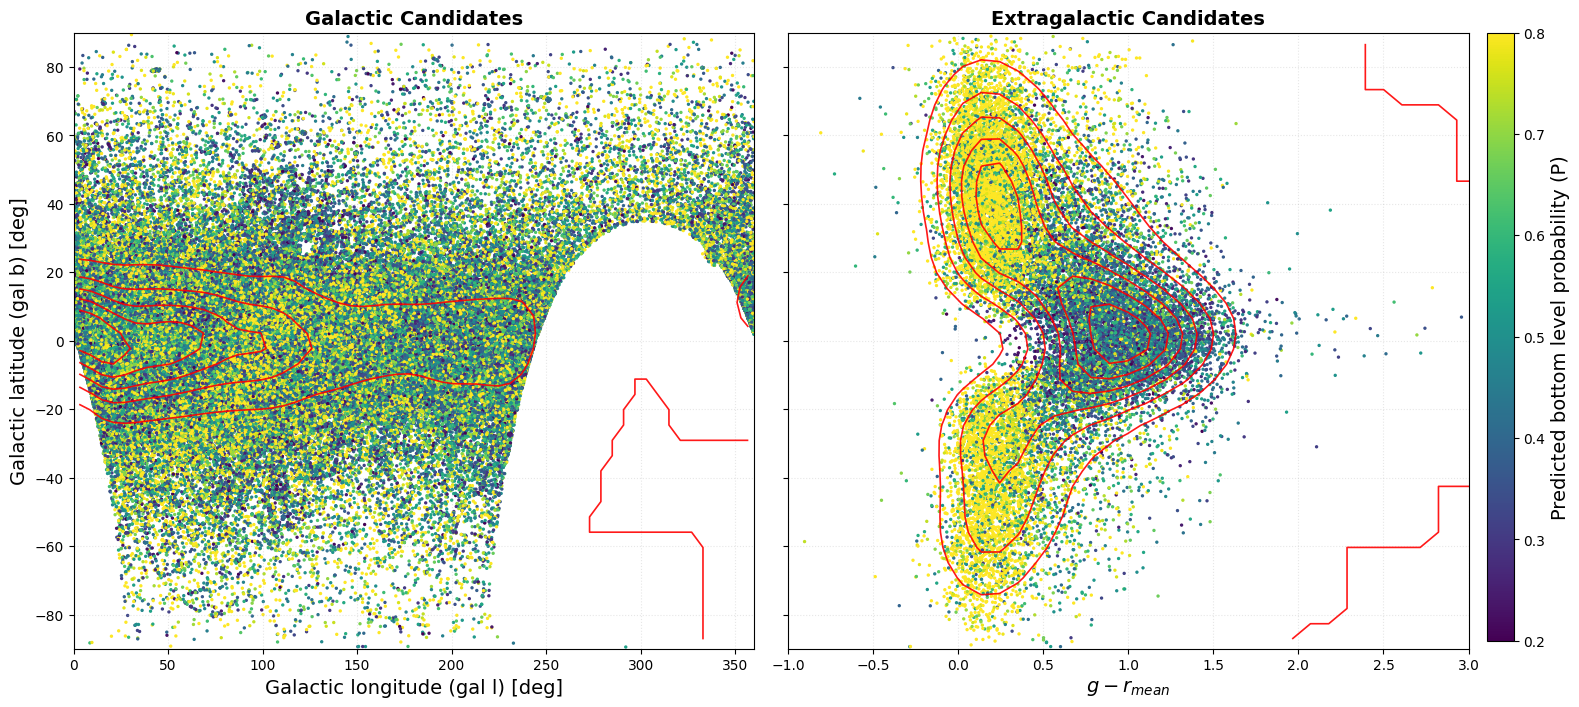

In [44]:
full_df = prepare_data(df_features, prob_mbappe_wide_bottom)
plot_figure_17_updated(full_df)